# 03 Alarm Distribution

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [ ]:
# THRESHOLD 31

alarms = pd.read_csv(
    "../outputs/reports/alarm_events_31.csv",
    parse_dates=[
        "start_time",
        "end_time"
    ]
)

print(alarms.shape)

alarms.head()

(70, 3)


,start_time,end_time,duration_minutes
0,2022-02-07 19:16:00,2022-02-07 19:16:00,0.0
1,2022-03-28 01:26:00,2022-03-28 05:31:00,245.0
2,2022-03-28 06:54:00,2022-03-28 08:43:00,109.0
3,2022-03-28 11:59:00,2022-03-28 11:59:00,0.0
4,2022-09-18 07:48:00,2022-09-18 07:49:00,1.0


In [19]:
# summary

print(f"Number of alarms: {len(alarms)}")

print(
    f"First alarm : {alarms['start_time'].min()}"
)

print(
    f"Last alarm  : {alarms['start_time'].max()}"
)

Number of alarms: 70
First alarm : 2022-02-07 19:16:00
Last alarm  : 2025-05-11 06:04:00


In [6]:
# alarm count by year

alarms["year"] = (
    alarms["start_time"]
    .dt.year
)

year_counts = (
    alarms
    .groupby("year")
    .size()
    .reset_index(name="count")
)

year_counts

,year,count
0,2022,7
1,2023,5
2,2024,55
3,2025,3


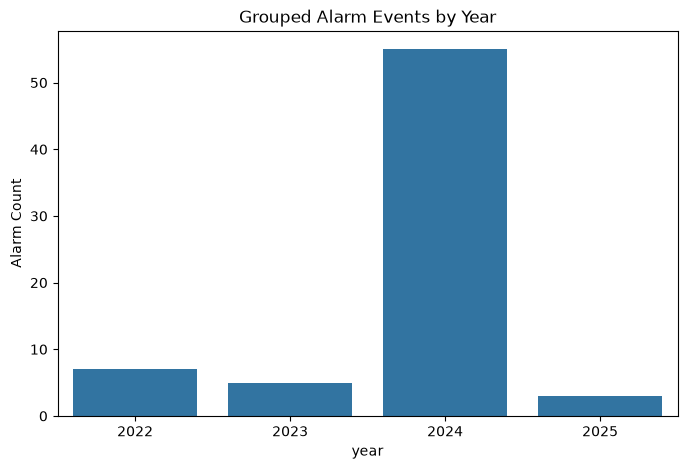

In [7]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=year_counts,
    x="year",
    y="count"
)

plt.title(
    "Grouped Alarm Events by Year"
)

plt.ylabel(
    "Alarm Count"
)

plt.show()

In [8]:
alarms["month"] = (
    alarms["start_time"]
    .dt.to_period("M")
    .astype(str)
)

month_counts = (
    alarms
    .groupby("month")
    .size()
    .reset_index(name="count")
)

month_counts.head()

,month,count
0,2022-02,1
1,2022-03,3
2,2022-09,1
3,2022-12,2
4,2023-01,2


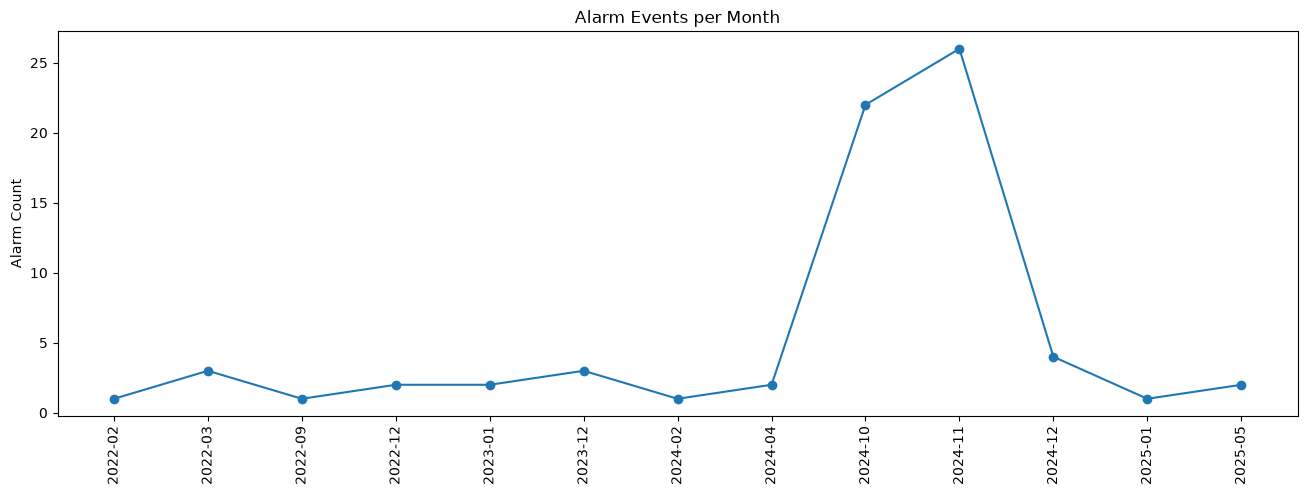

In [9]:
plt.figure(figsize=(16,5))

plt.plot(
    month_counts["month"],
    month_counts["count"],
    marker="o"
)

plt.xticks(
    rotation=90
)

plt.title(
    "Alarm Events per Month"
)

plt.ylabel(
    "Alarm Count"
)

plt.show()

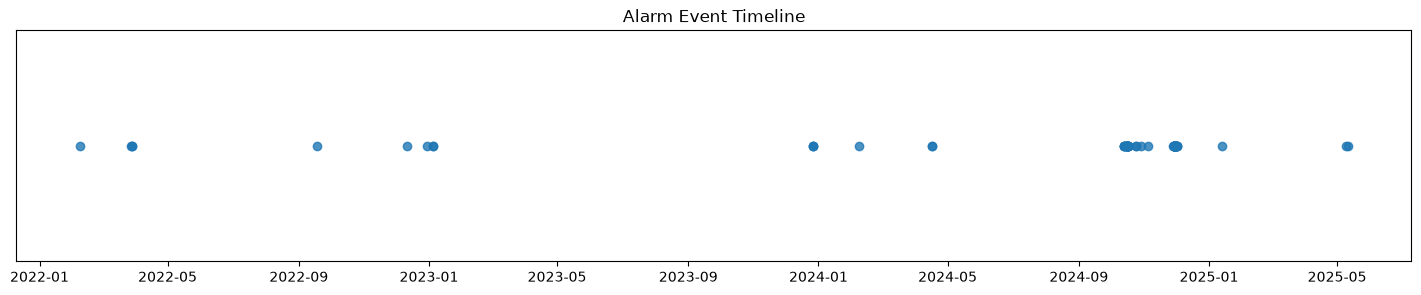

In [10]:
plt.figure(figsize=(18,3))

plt.scatter(
    alarms["start_time"],
    np.ones(len(alarms)),
    alpha=0.8
)

plt.title(
    "Alarm Event Timeline"
)

plt.yticks([])

plt.show()

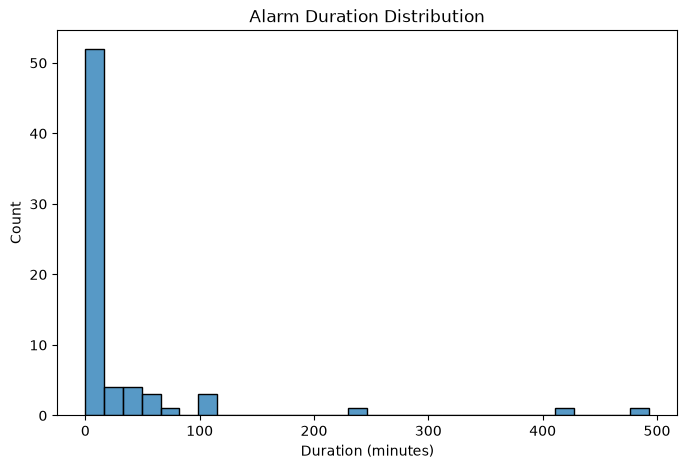

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    alarms["duration_minutes"],
    bins=30
)

plt.title(
    "Alarm Duration Distribution"
)

plt.xlabel(
    "Duration (minutes)"
)

plt.show()

In [12]:
alarms.sort_values(
    "duration_minutes",
    ascending=False
).head(20)

,start_time,end_time,duration_minutes,year,month
24,2024-10-15 21:36:00,2024-10-16 05:49:00,493.0,2024,2024-10
25,2024-10-16 06:27:00,2024-10-16 13:27:00,420.0,2024,2024-10
1,2022-03-28 01:26:00,2022-03-28 05:31:00,245.0,2022,2022-03
2,2022-03-28 06:54:00,2022-03-28 08:43:00,109.0,2022,2022-03
13,2024-04-16 05:56:00,2024-04-16 07:37:00,101.0,2024,2024-04
19,2024-10-15 06:42:00,2024-10-15 08:22:00,100.0,2024,2024-10
30,2024-10-16 19:57:00,2024-10-16 21:19:00,82.0,2024,2024-10
65,2024-12-02 01:30:00,2024-12-02 02:30:00,60.0,2024,2024-12
33,2024-10-17 00:58:00,2024-10-17 01:55:00,57.0,2024,2024-10
28,2024-10-16 17:06:00,2024-10-16 17:57:00,51.0,2024,2024-10


In [13]:
alarms[
    "duration_minutes"
].describe()

count     70.000000
mean      29.500000
std       83.119915
min        0.000000
25%        0.000000
50%        0.000000
75%       16.750000
max      493.000000
Name: duration_minutes, dtype: float64

In [14]:

alarm_density = (
    alarms
    .groupby("year")
    .agg(
        count=("year","size"),
        avg_duration=(
            "duration_minutes",
            "mean"
        )
    )
)

alarm_density

,count,avg_duration
year,,
2022,7,50.714286
2023,5,3.800000
2024,55,30.745455
2025,3,0.000000


In [15]:
year_counts.to_csv(
    "../outputs/reports/alarm_count_by_year.csv",
    index=False
)

month_counts.to_csv(
    "../outputs/reports/alarm_count_by_month.csv",
    index=False
)

In [16]:
year_counts

,year,count
0,2022,7
1,2023,5
2,2024,55
3,2025,3


In [17]:
month_counts.tail(20)

,month,count
0,2022-02,1
1,2022-03,3
2,2022-09,1
3,2022-12,2
4,2023-01,2
5,2023-12,3
6,2024-02,1
7,2024-04,2
8,2024-10,22
9,2024-11,26


In [20]:
# quarterly distribution
alarms["quarter"] = (
    alarms["start_time"]
    .dt.to_period("Q")
    .astype(str)
)

quarter_counts = (
    alarms
    .groupby("quarter")
    .size()
    .reset_index(name="count")
)

quarter_counts


,quarter,count
0,2022Q1,4
1,2022Q3,1
2,2022Q4,2
3,2023Q1,2
4,2023Q4,3
5,2024Q1,1
6,2024Q2,2
7,2024Q4,52
8,2025Q1,1
9,2025Q2,2


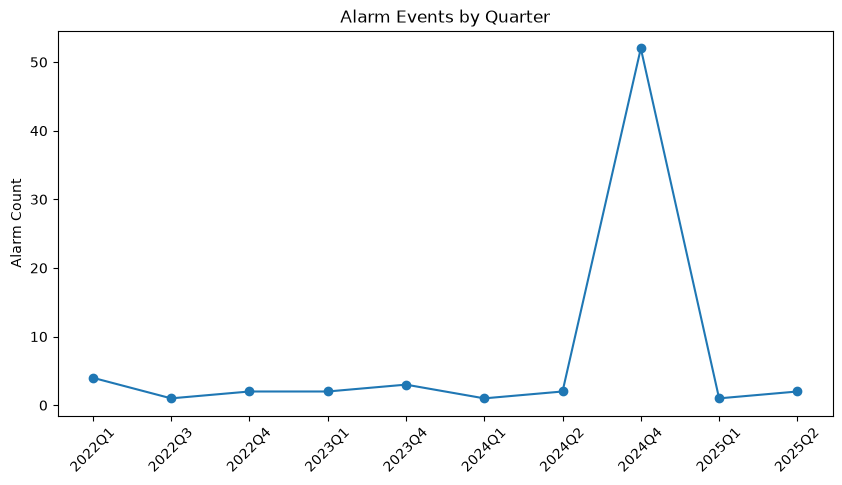

In [21]:
plt.figure(figsize=(10,5))

plt.plot(
    quarter_counts["quarter"],
    quarter_counts["count"],
    marker="o"
)

plt.xticks(rotation=45)

plt.title(
    "Alarm Events by Quarter"
)

plt.ylabel(
    "Alarm Count"
)

plt.show()

In [22]:
# first 20 alarm events

alarms.sort_values(
    "start_time"
)[
    [
        "start_time",
        "end_time",
        "duration_minutes"
    ]
].head(20)

,start_time,end_time,duration_minutes
0,2022-02-07 19:16:00,2022-02-07 19:16:00,0.0
1,2022-03-28 01:26:00,2022-03-28 05:31:00,245.0
2,2022-03-28 06:54:00,2022-03-28 08:43:00,109.0
3,2022-03-28 11:59:00,2022-03-28 11:59:00,0.0
4,2022-09-18 07:48:00,2022-09-18 07:49:00,1.0
5,2022-12-11 20:22:00,2022-12-11 20:22:00,0.0
6,2022-12-30 09:55:00,2022-12-30 09:55:00,0.0
7,2023-01-04 10:04:00,2023-01-04 10:11:00,7.0
8,2023-01-04 10:55:00,2023-01-04 10:55:00,0.0
9,2023-12-26 14:09:00,2023-12-26 14:09:00,0.0


In [23]:
# last 20 alarm events

alarms.sort_values(
    "start_time"
)[
    [
        "start_time",
        "end_time",
        "duration_minutes"
    ]
].tail(20)

,start_time,end_time,duration_minutes
50,2024-11-29 22:18:00,2024-11-29 22:18:00,0.0
51,2024-11-29 23:41:00,2024-11-29 23:41:00,0.0
52,2024-11-30 00:45:00,2024-11-30 00:45:00,0.0
53,2024-11-30 02:15:00,2024-11-30 02:15:00,0.0
54,2024-11-30 03:27:00,2024-11-30 03:56:00,29.0
55,2024-11-30 04:31:00,2024-11-30 04:54:00,23.0
56,2024-11-30 05:44:00,2024-11-30 06:01:00,17.0
57,2024-11-30 07:58:00,2024-11-30 08:03:00,5.0
58,2024-11-30 08:38:00,2024-11-30 08:59:00,21.0
59,2024-11-30 16:27:00,2024-11-30 16:27:00,0.0


In [24]:
# duration percentiles

alarms["duration_minutes"].quantile(
    [
        0.25,
        0.5,
        0.75,
        0.9,
        0.95,
        0.99
    ]
)

0.25      0.00
0.50      0.00
0.75     16.75
0.90     62.20
0.95    105.40
0.99    442.63
Name: duration_minutes, dtype: float64

In [25]:
alarms.sort_values(
    "duration_minutes",
    ascending=False
).head(20)

,start_time,end_time,duration_minutes,quarter
24,2024-10-15 21:36:00,2024-10-16 05:49:00,493.0,2024Q4
25,2024-10-16 06:27:00,2024-10-16 13:27:00,420.0,2024Q4
1,2022-03-28 01:26:00,2022-03-28 05:31:00,245.0,2022Q1
2,2022-03-28 06:54:00,2022-03-28 08:43:00,109.0,2022Q1
13,2024-04-16 05:56:00,2024-04-16 07:37:00,101.0,2024Q2
19,2024-10-15 06:42:00,2024-10-15 08:22:00,100.0,2024Q4
30,2024-10-16 19:57:00,2024-10-16 21:19:00,82.0,2024Q4
65,2024-12-02 01:30:00,2024-12-02 02:30:00,60.0,2024Q4
33,2024-10-17 00:58:00,2024-10-17 01:55:00,57.0,2024Q4
28,2024-10-16 17:06:00,2024-10-16 17:57:00,51.0,2024Q4


In [26]:
# compare thresholds by year

thresholds = [
    30,
    30.5,
    31,
    31.5,
    32
]

for t in thresholds:

    alarms = pd.read_csv(
        f"../outputs/reports/alarm_events_{t}.csv",
        parse_dates=[
            "start_time",
            "end_time"
        ]
    )

    alarms["year"] = (
        alarms["start_time"]
        .dt.year
    )

    print(f"\nThreshold {t}")

    print(
        alarms
        .groupby("year")
        .size()
    )


Threshold 30
year
2022     7
2023     4
2024    14
2025     3
dtype: int64

Threshold 30.5
year
2022     8
2023     5
2024    30
2025     3
dtype: int64

Threshold 31
year
2022     7
2023     5
2024    55
2025     3
dtype: int64

Threshold 31.5
year
2022    10
2023     5
2024    70
2025     4
dtype: int64

Threshold 32
year
2022     13
2023      5
2024    113
2025      5
dtype: int64


In [27]:
#compare thresholds by month
for t in thresholds:

    alarms = pd.read_csv(
        f"../outputs/reports/alarm_events_{t}.csv",
        parse_dates=[
            "start_time",
            "end_time"
        ]
    )

    alarms["month"] = (
        alarms["start_time"]
        .dt.to_period("M")
    )

    print(
        f"\nThreshold {t}"
    )

    print(
        alarms
        .groupby("month")
        .size()
        .tail(15)
    )



Threshold 30
month
2022-02     1
2022-03     3
2022-09     1
2022-12     2
2023-01     2
2023-12     2
2024-02     1
2024-04     2
2024-10    10
2024-12     1
2025-01     1
2025-05     2
Freq: M, dtype: int64

Threshold 30.5
month
2022-02     1
2022-03     4
2022-09     1
2022-12     2
2023-01     2
2023-12     3
2024-02     1
2024-04     2
2024-10    19
2024-11     6
2024-12     2
2025-01     1
2025-05     2
Freq: M, dtype: int64

Threshold 31
month
2022-02     1
2022-03     3
2022-09     1
2022-12     2
2023-01     2
2023-12     3
2024-02     1
2024-04     2
2024-10    22
2024-11    26
2024-12     4
2025-01     1
2025-05     2
Freq: M, dtype: int64

Threshold 31.5
month
2022-01     2
2022-02     1
2022-03     3
2022-08     1
2022-09     1
2022-12     2
2023-01     2
2023-12     3
2024-02     1
2024-04     2
2024-10    19
2024-11    33
2024-12    15
2025-01     1
2025-05     3
Freq: M, dtype: int64

Threshold 32
month
2022-01     4
2022-02     1
2022-03     2
2022-08     1
2022-09   

In [28]:
quarter_counts

,quarter,count
0,2022Q1,4
1,2022Q3,1
2,2022Q4,2
3,2023Q1,2
4,2023Q4,3
5,2024Q1,1
6,2024Q2,2
7,2024Q4,52
8,2025Q1,1
9,2025Q2,2


In [ ]:
# ALL THRESHOLDS

#YEAR DISTRIBUTION

thresholds = [30, 30.5, 31, 31.5, 32]

year_summary = []

for t in thresholds:

    alarms = pd.read_csv(
        f"../outputs/reports/alarm_events_{t}.csv",
        parse_dates=["start_time", "end_time"]
    )

    alarms["year"] = alarms["start_time"].dt.year

    counts = alarms.groupby("year").size()

    row = {
        "threshold": t,
        "2022": counts.get(2022, 0),
        "2023": counts.get(2023, 0),
        "2024": counts.get(2024, 0),
        "2025": counts.get(2025, 0),
    }

    year_summary.append(row)

year_summary = pd.DataFrame(year_summary)

year_summary

,threshold,2022,2023,2024,2025
0,30.0,7,4,14,3
1,30.5,8,5,30,3
2,31.0,7,5,55,3
3,31.5,10,5,70,4
4,32.0,13,5,113,5


In [30]:
# PERCENTAGE CONTRIBUTION BY YEAR

year_pct = year_summary.copy()

for year in ["2022", "2023", "2024", "2025"]:
    year_pct[year] = (
        year_pct[year]
        / year_pct[
            ["2022","2023","2024","2025"]
        ].sum(axis=1)
    ) * 100

year_pct

,threshold,2022,2023,2024,2025
0,30.0,25.000000,8.695652,27.615780,4.664800
1,30.5,17.391304,9.026688,50.489757,3.754329
2,31.0,10.000000,6.849315,73.480966,3.214391
3,31.5,11.235955,5.541029,77.112058,4.086259
4,32.0,9.558824,3.771910,86.042312,4.790509


In [31]:
# CONCENTRATION SCORE
year_pct["max_year_pct"] = (
    year_pct[
        ["2022","2023","2024","2025"]
    ].max(axis=1)
)

year_pct[
    ["threshold","max_year_pct"]
]

,threshold,max_year_pct
0,30.0,27.615780
1,30.5,50.489757
2,31.0,73.480966
3,31.5,77.112058
4,32.0,86.042312


In [ ]:
# final decision on threshold 

Alarm Event Distribution Analysis and Threshold Selection

The target variable 03TIC_1009.PV was analyzed using multiple candidate alarm thresholds (30.0, 30.5, 31.0, 31.5, and 32.0). Alarm events were generated by identifying periods where the target value fell below the threshold and subsequently grouping alarms occurring within a 30-minute interval into a single event.

Event Count Comparison
Threshold	Grouped Alarm Events
30.0	28
30.5	46
31.0	70
31.5	89
32.0	136

Increasing the threshold resulted in a larger number of alarm events. However, event count alone was not considered sufficient for threshold selection.

Temporal Distribution Analysis

To assess whether alarm events were representative of the entire operating history, the temporal distribution of grouped alarm events was analyzed across years and quarters.

The analysis revealed that thresholds greater than or equal to 31.0 produced a strong concentration of events within late 2024. For example:

Threshold 31.0: 73.5% of events occurred in 2024.
Threshold 31.5: 77.1% of events occurred in 2024.
Threshold 32.0: 86.0% of events occurred in 2024.

This indicates that higher thresholds predominantly capture a specific operating regime observed during late 2024 rather than representing the full historical behavior of the process.

In contrast, threshold 30.0 produced the most temporally balanced distribution but generated only 28 grouped alarm events, resulting in a very limited number of training samples.

Threshold Selection

A threshold of 30.5 was selected for subsequent forecasting experiments.

This threshold provides a compromise between:

Event availability – 46 grouped alarm events, representing a 64% increase over the 28 events obtained at threshold 30.0.
Temporal coverage – substantially better distribution across the observation period compared to thresholds ≥31.0.
Operational relevance – remaining close to the actual alarm threshold of 30.0 while providing additional early-warning samples for model training.
Final Configuration
BUSINESS_THRESHOLD = 30.0
FORECAST_THRESHOLD = 30.5
GROUP_GAP_MINUTES = 30

The operational alarm threshold remains fixed at 30.0, while 30.5 is used as the forecasting threshold for subsequent feature engineering, baseline modeling, and forecasting experiments.

Conclusion

Based on both event frequency and temporal distribution analysis, a forecasting threshold of 30.5 was selected as the most suitable threshold for model development. This threshold balances data availability and temporal representativeness while remaining closely aligned with the actual process alarm condition.